In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

# Set classic plot style
plt.style.use('classic')

In [3]:
# Define groups based on 'miso_data' and the previous 'mosi_data'
def group_miso_data(row):
    
    miso = str(row['miso_data'])
    previous_mosi = str(row['previous_mosi'])
    
    if "DATA_BLOCK" in miso :
        return "DATA_BLOCK"
    # elif "IDLE" in miso and "R1" in miso:
    #     return "R1, IDLE"
    elif "R1" in miso:
        if previous_mosi and "READ" in previous_mosi:
            return "R1 after READ"
        elif previous_mosi and "WRITE" in previous_mosi:
            return "R1 after WRITE"
        else:
            return "R1 after Command"
    elif "R7" in miso:
        return "R7"
    elif "R3" in miso:
        return "R3"
    else:
        print("rejected row" + str (row))
        return "OTHER"

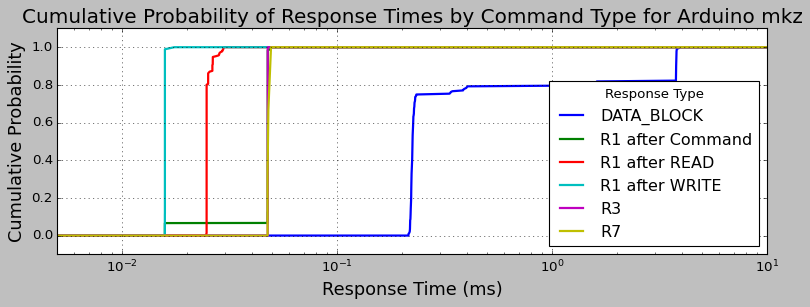

the group DATA_BLOCK has size 231
the group R1 after Command has size 1374
the group R1 after READ has size 231
the group R1 after WRITE has size 91
the group R3 has size 3
the group R7 has size 3


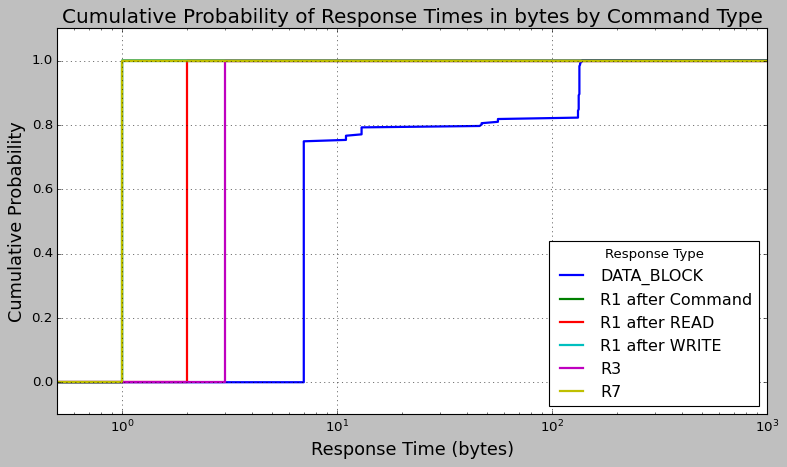

In [20]:

# Load CSV files into Pandas DataFrames
file1 = "CSVs/pi pico n1.csv"
file2 = "CSVs/pi pico n2.csv"
file3 = "CSVs/pi pico n3.csv"

# file1 = "CSVs/QWIIC openlog n1.csv"
# file2 = "CSVs/QWIIC openlog n2.csv"
# file3 = "CSVs/QWIIC openlog n3.csv"

# file1 = "CSVs/arduino mkz n1.csv"
# file2 = "CSVs/arduino mkz n2.csv"
# file3 = "CSVs/arduino mkz n3.csv"




# Replace these with the actual paths of your files
dataframes = [pd.read_csv(f) for f in [file1, file2, file3]]

# Combine all data into a single DataFrame
data = pd.concat(dataframes, ignore_index=True)

# Ensure 'type' and 'response_time(ms)' columns exist
if 'miso_data' not in data.columns or 'response_time(ms)' not in data.columns:
    raise ValueError("Missing required columns: 'miso_data' or 'response_time(ms)'")


# Add a column for the previous MOSI data
data['previous_mosi'] = data['mosi_data'].shift(1)

# Remove rows without 'miso_data' or time
data = data.dropna(subset=['miso_data'])
data = data.dropna(subset=['response_time(ms)'])
data = data.dropna(subset=['response_time(bytes)'])


# Apply grouping
data['group'] = data.apply(group_miso_data, axis=1)
# Group data by 'group'
grouped = data.groupby('group')

# Create cumulative probability plots
plt.figure(figsize=(10, 4))

for command_type, group in grouped:
    response_times = group['response_time(ms)'].dropna()
    if not response_times.empty:
        sorted_times = np.sort(response_times)
        cumulative_probs = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

        # Add points for horizontal segments at 0 and 1
        sorted_times = np.insert(sorted_times, 0,sorted_times[0])
        cumulative_probs = np.insert(cumulative_probs, 0, 0)
        sorted_times = np.insert(sorted_times, 0,sorted_times[0]/1000)
        cumulative_probs = np.insert(cumulative_probs, 0, 0)
        sorted_times = np.append(sorted_times, sorted_times[-1] * 1000)
        cumulative_probs = np.append(cumulative_probs, 1)

        plt.semilogx(sorted_times, cumulative_probs, label=command_type, linewidth= 2)

# Add plot details
plt.title('Cumulative Probability of Response Times by Command Type for Arduino mkz', size = 18)
plt.xlabel('Response Time (ms)', size = 16)
plt.ylabel('Cumulative Probability', size = 16)
plt.legend(title='Response Type', loc='lower right')
plt.grid(True)
plt.ylim(-0.1,1.1)
plt.xlim(0.005,10)

# Save or show the plot
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))

for command_type, group in grouped:
    print("the group " + str(command_type) + " has size " + str(len(group)))

    response_times = group['response_time(bytes)'].dropna()
    if not response_times.empty:
        sorted_times = np.sort(response_times)
        cumulative_probs = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

        # Add points for horizontal segments at 0 and 1
        sorted_times = np.insert(sorted_times, 0,sorted_times[0])
        cumulative_probs = np.insert(cumulative_probs, 0, 0)
        sorted_times = np.insert(sorted_times, 0,sorted_times[0]/1000)
        cumulative_probs = np.insert(cumulative_probs, 0, 0)
        sorted_times = np.append(sorted_times, sorted_times[-1] * 1000)
        cumulative_probs = np.append(cumulative_probs, 1)

        plt.semilogx(sorted_times, cumulative_probs, label=command_type, linewidth= 2)

# Add plot details
plt.title('Cumulative Probability of Response Times in bytes by Command Type', size = "18")
plt.xlabel('Response Time (bytes)', size = 16)
plt.ylabel('Cumulative Probability', size = 16)
plt.legend(title='Response Type', loc='lower right')
plt.grid(True)
plt.ylim(-0.1,1.1)
plt.xlim(0.5,1000)

# Save or show the plot
plt.tight_layout()
plt.show()



<Figure size 800x480 with 0 Axes>

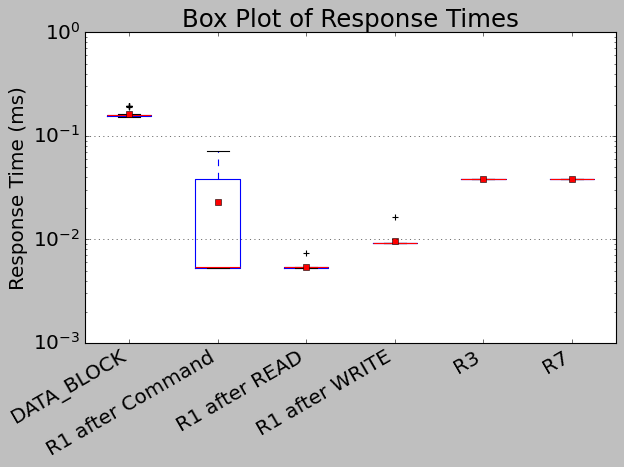

<Figure size 800x480 with 0 Axes>

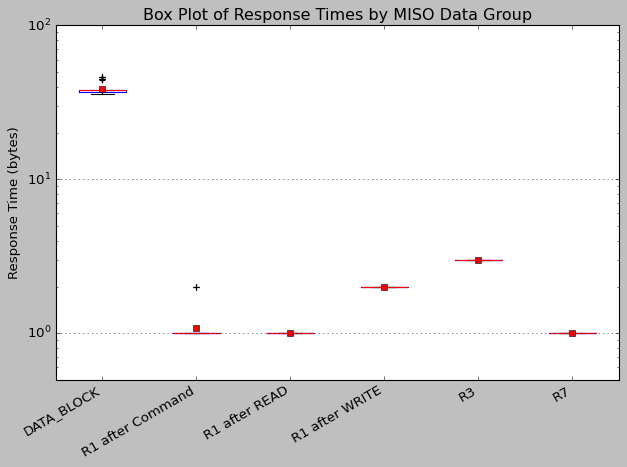

In [13]:
# Create box plot for response times by group
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()

response_time_data = [group['response_time(ms)'].dropna() for _, group in grouped]
ax.boxplot(response_time_data, labels=grouped.groups.keys(),showfliers=True, showmeans=True)
ax.set_yscale('log')

# Add labels and titles
plt.title('Box Plot of Response Times', size = 22)
plt.ylabel('Response Time (ms)', size = 18)
plt.yticks(size = 18)
plt.xticks(rotation=30, ha='right', size = 18)
plt.tight_layout()
plt.grid(axis='y')

# Show the plot
plt.show()

# Create box plot for response times by group
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()

response_time_data = [group['response_time(bytes)'].dropna() for _, group in grouped]
ax.boxplot(response_time_data, labels=grouped.groups.keys(),showfliers=True, showmeans=True)
ax.set_yscale('log')

# Add labels and titles
plt.title('Box Plot of Response Times by MISO Data Group')
plt.ylabel('Response Time (bytes)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.ylim(0.5,100)

# Show the plot
plt.show()

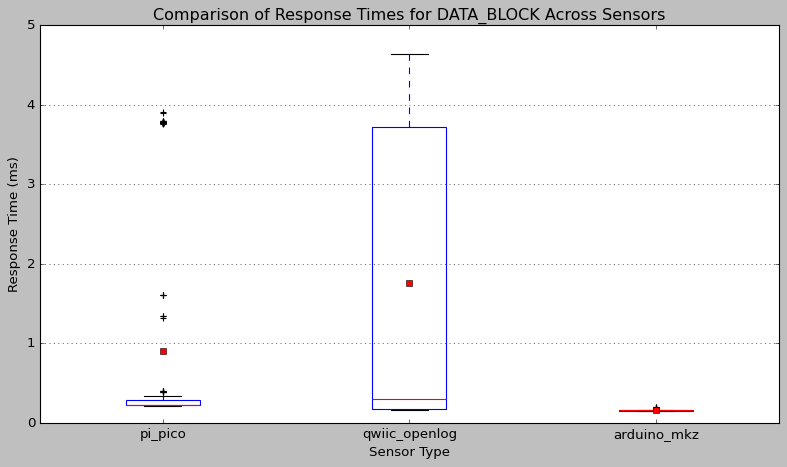

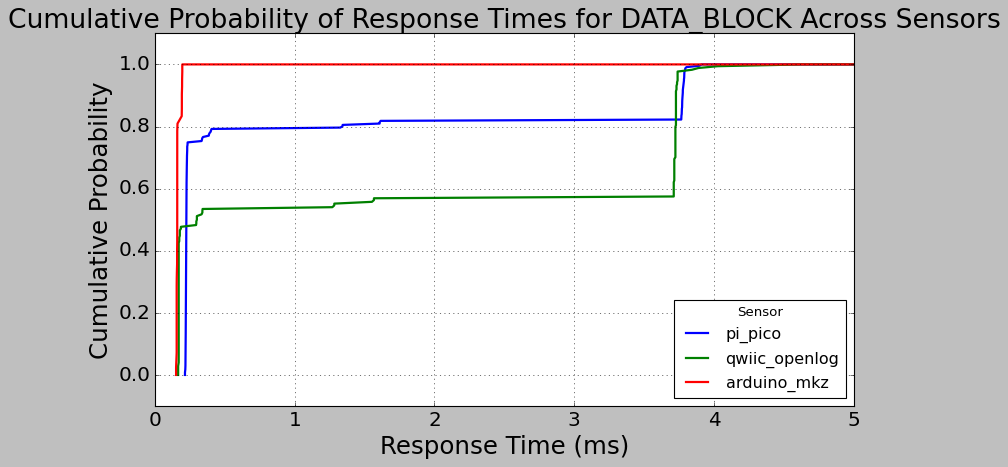

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set classic plot style
plt.style.use('classic')

# Define file paths for different sensors
sensors = {
    "pi_pico": ["CSVs/pi pico n1.csv", "CSVs/pi pico n2.csv", "CSVs/pi pico n3.csv"],
    "qwiic_openlog": ["CSVs/QWIIC openlog n1.csv", "CSVs/QWIIC openlog n2.csv", "CSVs/QWIIC openlog n3.csv"],
    "arduino_mkz": ["CSVs/arduino mkz n1.csv", "CSVs/arduino mkz n2.csv", "CSVs/arduino mkz n3.csv"]
}

# Choose the sensor to analyze
sensor_name = "arduino_mkz"  # Change this to "pi_pico" or "qwiic_openlog" as needed
file1, file2, file3 = sensors[sensor_name]

# Load CSV files into Pandas DataFrames
dataframes = [pd.read_csv(f) for f in [file1, file2, file3]]

# Combine all data into a single DataFrame
data = pd.concat(dataframes, ignore_index=True)

# Ensure 'type', 'miso_data', 'response_time(ms)', and 'response_time(bytes)' columns exist
required_columns = ['miso_data', 'mosi_data', 'response_time(ms)', 'response_time(bytes)']
if not all(col in data.columns for col in required_columns):
    raise ValueError(f"Missing one or more required columns: {required_columns}")

# Remove rows without 'miso_data' or response times
data = data.dropna(subset=['miso_data', 'response_time(ms)', 'response_time(bytes)'])

# Add a column for the previous MOSI data
data['previous_mosi'] = data['mosi_data'].shift(1)

# Define groups for DATA_BLOCK by sensor type
def group_data_block(row):
    miso = row['miso_data']
    if miso.startswith("DATA_BLOCK"):
        return "DATA_BLOCK"
    return "OTHER"

# Apply grouping based on DATA_BLOCK
data['group'] = data.apply(group_data_block, axis=1)

# Filter for DATA_BLOCK responses
data_block_data = data[data['group'] == "DATA_BLOCK"]

# Compare response times across sensors
plt.figure(figsize=(10, 6))

# Group response times by 'sensor' for DATA_BLOCK
sensor_groups = []
for sensor, files in sensors.items():
    temp_frames = [pd.read_csv(f) for f in files]
    sensor_data = pd.concat(temp_frames, ignore_index=True)
    sensor_data = sensor_data.dropna(subset=['miso_data', 'response_time(ms)'])
    sensor_data['group'] = sensor_data.apply(group_data_block, axis=1)
    filtered_data = sensor_data[sensor_data['group'] == "DATA_BLOCK"]
    sensor_groups.append((sensor, filtered_data['response_time(ms)']))

# Box plot styling for DATA_BLOCK comparisons
response_times = [times.dropna() for _, times in sensor_groups]
sensor_labels = [sensor for sensor, _ in sensor_groups]
plt.boxplot(response_times, labels=sensor_labels, patch_artist=True, showmeans=True)

# Add labels and titles
plt.title('Comparison of Response Times for DATA_BLOCK Across Sensors')
plt.xlabel('Sensor Type')
plt.ylabel('Response Time (ms)')
plt.grid(axis='y')
plt.tight_layout()

# Show the plot
plt.show()

# Cumulative probability plot for DATA_BLOCK
plt.figure(figsize=(10, 6))
for sensor, times in sensor_groups:
    if not times.empty:
        sorted_times = np.sort(times.dropna())
        cumulative_probs = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

        # Add horizontal segments at 0 and 1
        sorted_times = np.insert(sorted_times, 0, sorted_times[0])
        cumulative_probs = np.insert(cumulative_probs, 0, 0)
        sorted_times = np.append(sorted_times, sorted_times[-1] * 1000)
        cumulative_probs = np.append(cumulative_probs, 1)

        plt.plot(sorted_times, cumulative_probs, label=sensor, linewidth=2)

# Add plot details
plt.title('Cumulative Probability of Response Times for DATA_BLOCK Across Sensors', size = 24)
plt.xlabel('Response Time (ms)', size = 22)
plt.ylabel('Cumulative Probability', size = 22)
plt.legend(title='Sensor', loc='lower right')
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.xlim(0.0, 5)
plt.xticks(size =18)
plt.yticks(size =18)
plt.tight_layout()

# Show the plot
plt.show()
